# Optimization 4 - Constrained Optimization

In [1]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(seed=42)

# Configure Seaborn.
sns.set_style("whitegrid")
sns.set_palette("deep")

## 1 The Constraint

### 1.1 Loss Function

We use Gradient Descent algorithm to find best weight vector $w^*, w_0^*$ by optimizing/minimizing the Loss function.

#### Optimization of Loss Function

Equation for **Optimization of Loss Function** for Binary Classification can be expanded as:

$$
\large
\begin{aligned}
w^*, w_0^* &= \arg\min_{w, w_0} \;\; l(D, \vec{w}, w_0) \\[10pt]
           &= \arg\min_{w, w_0}\;-\frac{1}{n}\sum_{i=1}^n\Biggl(\frac{w^T x^{(i)}\;+\;w_0}{\Vert{w}\Vert}\Biggr)\cdot y^{(i)} \\[10pt]
           &= \arg\min_{w, w_0}\;-\frac{1}{n}\sum_{i=1}^n\Biggl(\frac{w^T x^{(i)}\;+\;w_0}{\sqrt{w_1^2 + w_2^2 + \ldots + w_n^2}}\Biggr)\cdot y^{(i)} \\[10pt]
           &= \arg\min_{w, w_0}\;-\frac{1}{n}\sum_{i=1}^n\Biggl(\frac{w^T x^{(i)}\;+\;w_0}{\sqrt{\vec{w}^2}}\Biggr)\cdot y^{(i)}
\end{aligned}
$$

### 1.2 Derivative of Loss Function

Given loss function:

$$
\large
\begin{aligned}
l(D, \vec{w}, w_0) = -\frac{1}{n}\sum_{i=1}^n\Biggl(\frac{w^T x^{(i)}\;+\;w_0}{\Vert{w}\Vert}\Biggr)\cdot y^{(i)}
\end{aligned}
$$

Discarding $y$, function to represent optimization of a single data-point can be written as:

$$
\large
\begin{aligned}
f(\vec{w}, w_0) = \frac{w_1 x_1 + w_2 x_2 + \ldots +  w_d x_d + w_0}{\sqrt{w_1^2 + w_2^2 + \ldots + w_d^2}}
\end{aligned}
$$

The partial derivatives of $f(\vec{w}, w_0)$ can be calculated as:

$$
\large
\begin{aligned}
\frac{\partial}{\partial{\vec{w}}} f(\vec{w}, w_0) \\[8pt]
\frac{\partial}{\partial{w_0}} f(\vec{w}, w_0)
\end{aligned}
$$

Above equation represents the form:

$$
\large
\begin{aligned}
h(w) = \frac{f(w)}{g(w)} = \frac{w_1 x_1 + w_2 x_2 + \ldots +  w_d x_d + w_0}{\sqrt{w_1^2 + w_2^2 + \ldots + w_d^2}}
\end{aligned}
$$

To get derivatives of above function $h(x)$ we can apply Quotient rule given below:

$$
\large
\begin{aligned}
\frac{d}{dx} \Biggl[\frac{f(x)}{g(x)}\Biggr] = \frac{g(x)\frac{d}{dx}f(x) - f(x)\frac{d}{dx}g(x)}{\bigl[g(x)\bigr]^2}
\end{aligned}
$$

But we know that:

$$
\large
\begin{aligned}
\frac{\partial}{\partial\vec{w}} (w_1 x_1 + \ldots +  w_d x_d + w_0) = \vec{x}
\end{aligned}
$$

$$
\large
\begin{aligned}
\nabla_{\vec{w}}\;(w^T{x} + w_0) = \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_d \end{bmatrix}
\end{aligned}
$$

i.e., Gradient Vector of weight vector $\vec{w}$ is its feature vector $\vec{x}$.

and also know that:

$$
\large
\begin{aligned}
\frac{\partial}{\partial\vec{x}} (x^T x) = 2\cdot\vec{x}
\end{aligned}
$$

$$
\large
\begin{aligned}
\nabla_{\vec{x}}\;(x^T x) = 2 \times \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_d \end{bmatrix}
\end{aligned}
$$

i.e., Gradient Vector of a dot product between same vectors is a scalar product between 2 and that vector itself.

### 1.3 Complex Minimization

#### The Constraint

Finding derivatives for below equation is very complex:

$$
\large
\begin{aligned}
\frac{w_1 x_1 + w_2 x_2 + \ldots +  w_d x_d + w_0}{\sqrt{w_1^2 + w_2^2 + \ldots + w_d^2}}
\end{aligned}
$$

Here the problem is denominator, which can be simplified by making some assumptions (or setting some constraints).

Based on our understanding below:

- We know that **Gradient vector** $\nabla f$ at any given point represents the **steepness** (towards ascent) and **direction** (towards maxima).
- Therefore **negative** of $\nabla f$ vector i.e., $-\nabla f$ Vector automatically points in the **direction of minima**.
- It is only useful to know the direction of $-\nabla f$ vector and its **magnitude has no significance**.

We can set a below constrain to simplify the equation:

$$
\large
\begin{aligned}
\boxed{
\rule{0pt}{15pt} \\
\quad \Vert\vec{w}\Vert = 1 \quad \\[10pt]
}
\end{aligned}
$$

i.e., the magnitude of weight vector will always be equal to 1.

### 1.4 Example

#### Example #1

Find the minima of given $f(x)$, such that it satisfies the constraint: $2x^2 - 3x + 1 = 0$

$$
\large
\begin{aligned}
f(x) &= x^2 - 3x + 3
\end{aligned}
$$

##### PART 1: Minimization

**STEP 1**: Compute first derivative.

$$
\large
\begin{aligned}
f^\prime(x) = 2x - 3
\end{aligned}
$$

**STEP 2**: Find Critical value.

$$
\large
\begin{aligned}
f^\prime(x) &= 0 \\[5pt]
     2x - 3 &= 0 \\[5pt]
          x &= \frac{3}{2} \\[5pt]
            &= 1.5  
\end{aligned}
$$

**STEP 3**: Identify Minima

$$
\large
\begin{aligned}
f^{\prime\prime}(x) &= 2 \\[5pt]
                  2 &> 0
\end{aligned}
$$

Hence $f(x)$ takes minimum value at critical value of $x$:

$$
\large
\begin{aligned}
x = 1.5
\end{aligned}
$$

**STEP 4**: Calculate minima value.

$$
\large
\begin{aligned}
f(x) &= \biggl(\frac{3}{2}\biggr)^2 - 3 \biggl(\frac{3}{2}\biggr) + 3 \\[10pt]
     &= 0.75
\end{aligned}
$$

Hence minima is located at: $\bigl(x, f(x)\bigr) = (1.5, 0.75)$

##### PART 2: Constraint Optimization

Plotting the constraint: $2x^2 - 3x + 1$ and $f(x) = x^2 - 3x + 3$ and solving using visualization:

https://www.desmos.com/calculator/aaurlqyzhj

Both the equation intersect at At $\bigl(x, f(x)\bigr) = (1.414, 0.757) \approx (1.5, 0.75)$

### 1.5 Summary

- In order to minimize the complexity in calculating the partial derivatives of loss function certain constrains are introduced.
- Since there is no significance of the magnitude of a Gradient vector, a constraint is set to always equate it to 1.
- Setting a constraint alters the Optimization process followed earlier and requires **Constrain Optimization**.

## 2 Constraint Optimization

### 2.1 New Optimization Problem

#### What is Constraint Optimization?

Constraint Optimization is the process of loss minimization of a function such that the target constraint is satisfied.

New Optimization equation has two parts loss minimization and target constraint:

$$
\large
\begin{aligned}
w^*, w_0^* &= \arg\min_{\vec{w},w_0}\;\;l(D, \vec{w},w_0) & \text{such that}:\;\Vert{\vec{w}}\Vert = 1 \\[10pt]
           &= \arg\min_{\vec{w},w_0}\;-\frac{1}{n}\sum_{i=1}^n\Biggl(\frac{w^T x^{(i)}\;+\;w_0}{\Vert{w}\Vert}\Biggr)y^{(i)} & \text{such that}:\;\Vert{\vec{w}}\Vert = 1
\end{aligned}
$$

Above equation can be solved using Lagrange Function.

### 2.2 Lagrangian Function

#### Lagrange Multiplier

$$
\large
\begin{aligned}
\mathcal{L}(x, \lambda) \equiv f(x)\;+\;\lambda\cdot{g(x)}
\end{aligned}
$$

Where $\lambda$ is called as Lagrange Multiplier.

#### Lagrange Multiplier for Constraint Optimization

Applying Lagrange Multiplier on Optimization equation:

$$
\large
\begin{aligned}
w^*, w_0^* &= \arg\min_{\vec{w},w_0,\lambda}\;\;l\bigl(D,\vec{w},w_0,\lambda\bigr) \\[10pt]
           &= \arg\min_{\vec{w},w_0,\lambda}\;-\frac{1}{n}\sum_{i=1}^n\Bigl(w^T x^{(i)}\;+\;w_0\Bigr)y^{(i)}\;+\;\lambda \bigl(\Vert{\vec{w}}\Vert - 1\bigr)
\end{aligned}
$$

##### Why magnitude of w vector minus 1?

$$
\large
\begin{aligned}
    \Vert{\vec{w}}\Vert &= 1 \\[5pt]
\Vert{\vec{w}}\Vert - 1 &= 0
\end{aligned}
$$

### 2.3 Examples

#### Example 1

### 2.4 GD Algorithm with LM

#### Old GD Update Rule

$$
\large
\begin{aligned}
w^n = x^o - \eta \frac{\partial}{\partial\;{w}} f(w, w_0) \\[8pt]
w_0^n = w_0^o - \eta \frac{\partial}{\partial\;{w_0}} f(w, w_0)
\end{aligned}
$$

Where,

- $w$ - Weight vector
- $w_0$ - Bias

#### New GD Update Rule with LM

$$
\large
\begin{aligned}
w^n = x^o - \eta \frac{\partial}{\partial\;{w}} f(w, w_0, \lambda) \\[8pt]
w_0^n = w_0^o - \eta \frac{\partial}{\partial\;{w_0}} f(w, w_0, \lambda)
\end{aligned}
$$

Where,

- $w$ - Weight vector
- $w_0$ - Bias

$$
\large
\begin{aligned}
\vec{w}^{t+1} &= \vec{w}^t - \eta\Biggl[-\sum_{i=1}^n x_i \cdot y_i + \lambda\frac{\vec{w}^t}{\Vert{\vec{w}^t}\Vert}\Biggr] \\[10pt]
    w_0^{t+1} &= w_0^t - \eta\Biggl[-\sum_{i=1}^n y_i\Biggr]
\end{aligned}
$$

Where,

$\lambda$ is the regularizer

> **Note**:
>
> 1. Gradient of weight vector $w$ before Constraint Optimization was feature vector $x$
> 2. Gradient of weight vector $w$ after Constraint Optimization was feature vector $x \cdot y$

## 3 Flavors of Gradient Descent

### 3.1 Epoch

#### What is an Epoch?

One epoch is defined as one complete iteration of entire dataset.

Given a dataset $D$ where $D$ is defined as:

$$
\large
\begin{aligned}
D := \biggl\{\bigl(x_i, y_i \bigr)\;;\;x\in\mathbb{R}^d\;;\;y\in\{-1,+1\}\biggr\}_{i=1}^n
\end{aligned}
$$

One epoch is when all $n$ rows in the dataset $D$ are used for some calculation.

### 3.2 Types of Gradient Descent

There are three types of Gradient Descent Algorithm based on number of rows used in weights calculation:

1. Vanilla Gradient Descent
2. Stochastic Gradient Descent
3. Batch Gradient Descent

#### 1 Vanilla Gradient Descent

##### Properties

$$
\large
\begin{aligned}
\vec{w}^{t+1} = \vec{w}^t - \eta\Biggl[-\sum_{i=1}^n x_i \cdot y_i + \lambda\frac{\vec{w}^t}{\Vert{\vec{w}^t}\Vert}\Biggr]
\end{aligned}
$$

- Entire dataset is used to compute the weights.
- Weights are updated after computing gradients using **all rows** from the dataset.
- Weights are updated **only once per Epoch**.

##### Advantages

Most **accurate** of all the three variants of GD since entire dataset is used to updated weights.

##### Disadvantages

Training process is **inefficient** consumes lot of time and compute power since entire dataset is used each time while computing new weights.

#### 2 Stochastic Gradient Descent

##### Properties

$$
\large
\begin{aligned}
\vec{w}^{t+1} = \vec{w}^t - \eta\Biggl[- (x_i \cdot y_i) + \lambda\frac{\vec{w}^t}{\Vert{\vec{w}^t}\Vert}\Biggr]
\end{aligned}
$$

- One row is used at a time to compute the weights.
- Weights are updated immediately after computing gradients using **single row** from the dataset.
- Weights are updated **$n$ times in an Epoch**.

##### Advantages

Most **efficient** of all the three variants of GD since only one dataset is used to updated weights.

##### Disadvantages

Results in **zigzag** Learning i.e., one odd datapoint can diverge/subvert the loss minimization towards minima.

#### 3 Mini-Batch Gradient Descent

##### Properties

$$
\large
\begin{aligned}
\vec{w}^{t+1} = \vec{w}^t - \eta\Biggl[-\sum_{i=1}^b x_i \cdot y_i + \lambda\frac{\vec{w}^t}{\Vert{\vec{w}^t}\Vert}\Biggr]
\end{aligned}
$$

Where $b < n$

- Dataset is divided into $k$ number of batches where each batch is of size $b$ where $b < n$.
- $b$ number of rows are used to compute the weights.
- Weights are updated $k$ number of times per Epoch.
- Adds new Hyper-parameter batch size $b$ for tuning.

##### Advantages

- Mini-Batch Gradient Descent is more efficient when compared with Vanilla Gradient Descent.
- Mini-Batch Gradient Descent is more accurate when compared with Stochastic Gradient Descent.

##### Disadvantages

- Mini-Batch Gradient Descent is less accurate when compared with Vanilla Gradient Descent.
- Mini-Batch Gradient Descent is less efficient when compared with Stochastic Gradient Descent.

### 3.3 Implementation

Simple implementation of Gradient Descent Algorithm in Python.

#### Helper Functions

In [2]:
def get_batches(X, Y, batch_size=None):
    """
    Function to create batches of data from `X` and `Y`.
    """
    n = len(Y)
    b = n if batch_size is None else batch_size  # Batch size
    data = np.concatenate((X, Y), axis=1)

    splits = np.arange(b, len(data), b)
    batches = np.array_split(data, splits)

    return batches

In [3]:
def lagrange_multiplier(lamda, w_vec):
    """
    Function to calculate Lagrange Multiplier.
    """
    # w_mag = np.linalg.norm(w_vec)
    # lm = 0 if w_mag == 0 else lamda * (w_vec / w_mag)

    lm = 2 * lamda * w_vec

    return lm

In [4]:
def get_error(w, w_0, X, Y):
    """
    Function to calculate error.
    """
    dot_prod = w.T @ X.T + w_0
    mag = np.linalg.norm(w)

    # Calculate error.
    error = (dot_prod / mag) * Y.T

    # avg_error = np.dot(dot_prod / mag, Y)
    # avg_error = np.mean(error, where=error < 0)
    avg_error = np.mean(error)

    return avg_error

In [5]:
def check_convergence(w_old, bias_old, w_new, bias_new):
    """
    Function to check convergence of weight vector an bias.
    """
    # Vertically stack weights and bias into single vector.
    old_vec = np.vstack((w_old, bias_old.reshape((1, 1))))
    new_vec = np.vstack((w_new, bias_new.reshape((1, 1))))

    return np.allclose(new_vec, old_vec, rtol=1e-06, atol=1e-08)

In [6]:
def check_convergence2(w_old, w0_old, w_new, w0_new):
    """
    Function to check convergence of weight vector an bias.
    """
    w_tolerance = np.allclose(w_new, w_old, rtol=1e-06, atol=1e-08)
    w0_tolerance = np.allclose(w0_new, w0_old, rtol=1e-04, atol=1e-06)

    return w_tolerance and w0_tolerance

In [7]:
def plot_errors(errors):
    """
    Function to plot error value in each iteration.
    """
    if len(errors) == 0:
        return

    plt.figure(figsize=(10, 4))

    sns.lineplot(x=range(len(errors)), y=errors)
    plt.title("Error vs Iterations")
    plt.xlabel("Iterations")
    plt.ylabel("Error")

    plt.show()

#### Gradient Update Rule

In [8]:
def apply_gur(w_t, w0_t, batches, eta=0.001, lamda=0.001):
    """
    Function to perform Gradient Update Rule on one Epoch.

    The flavor of GD applied depends on batches:
       1. One batch with size = `n` ->    Vanilla Gradient Descent
       2. `n` batches of size =  1  -> Stochastic Gradient Descent
       3. `k` batches of size = `b` -> Mini-batch Gradient Descent
    """
    w_tp1 = None  # Weight vector
    w0_tp1 = None  # Bias

    for batch in batches:
        # Split X and Y.
        x = batch[:, :-1]  # All rows and columns except last column.
        y = batch[:, -1:]  # All rows but only last column.

        # Regularization.
        reg = 2 * lamda * w_t

        # Calculate Gradient Vector.
        grad_vec = np.mean(x * y, axis=0).reshape(-1, 1) - reg

        # Update weight vector.
        w_tp1 = w_t + (eta * grad_vec)
        w_t = w_tp1

        # Update bias.
        w0_tp1 = w0_t + eta * np.mean(y)
        # print("Old bias:", w0_t, "New bias:", w0_tp1)
        w0_t = w0_tp1

    return w_tp1, w0_tp1

#### Gradient Descent Algorithm

In [9]:
def gradient_descent(X, Y, lr=0.001, regularizer=0.001, batch_size=None, bias=0):
    """
    Implementation of Gradient Descent Algorithm.

    The flavor of the Gradient Descent applied on the input
    dataset: `(X, Y)` depends on the `batch_size` parameter.
    """
    n, d = X.shape
    convergence = False
    w_old = np.zeros(shape=(d, 1))
    w0_old = np.array([bias])
    w_new = None
    w0_new = None
    errors = []

    # Initialize Hyper-parameters.
    eta = lr
    lamda = regularizer

    # Prepare batches from input dataset.
    batches = get_batches(X, Y, batch_size)

    # Initialize iteration parameters.
    itr_count = 0
    max_iter = 10_000
    while (not convergence) and (itr_count < max_iter):
        # Apply Gradient Update Rule (GUR) on one Epoch of dataset.
        w_new, w0_new = apply_gur(w_old, w0_old, batches, eta, lamda)

        # Check for convergence of weight vector and bias.
        if check_convergence2(w_old, w0_old, w_new, w0_new):
            convergence = True

        # Log errors in each iteration for plotting.
        errors.append(get_error(w_new, w0_new, X, Y))

        # Update weights.
        w_old = w_new
        w0_old = w0_new
        itr_count += 1

    if itr_count == max_iter:
        warnings.warn("Max iteration reached. Try increasing learning rate.")

    print(f"It took {itr_count} epochs to find optimum weights.")

    return w_new, w0_new, errors

## 4 Examples

### 4.1 Example #1: Imbalanced Dataset

#### Test Dataset

In [10]:
f1 = [1, 2, 3, 4, 5, 5, 6, 7, 8]  # Feature #1
f2 = [1, 2, 3, 4, 5, 1, 2, 3, 4]  # Feature #2
cl = [1, 1, 1, 1, 1, -1, -1, -1, -1]  # Class Label

d = 2  # Dimensions (Number of features)
n = len(cl)
X = np.column_stack((f1, f2))
Y = np.array(cl).reshape((n, 1))
data = np.concat((X, Y), axis=1)
rng.shuffle(data)

print("Dataset:")
display(data)
print("\nShape:", data.shape)

Dataset:


array([[ 4,  4,  1],
       [ 1,  1,  1],
       [ 7,  3, -1],
       [ 3,  3,  1],
       [ 5,  5,  1],
       [ 6,  2, -1],
       [ 2,  2,  1],
       [ 5,  1, -1],
       [ 8,  4, -1]])


Shape: (9, 3)


#### Plot Dataset

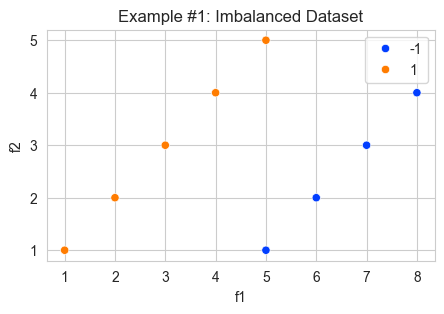

In [11]:
plt.figure(figsize=(5, 3))

sns.scatterplot(x=f1, y=f2, hue=cl, palette="bright")
plt.title("Example #1: Imbalanced Dataset")
plt.xlabel("f1")
plt.ylabel("f2")

plt.show()

#### Optimization

##### 1 Vanilla Gradient Descent

In [12]:
# Hyper-parameters.
eta = 0.002  # Learning Rate.
lamda = 0.75  # Large value of lambda is recommended for small dataset.
bias = 0.1

w, w_0, errors = gradient_descent(X, Y, lr=eta, regularizer=lamda, bias=bias)

It took 9507 epochs to find optimum weights.


##### 2 Stochastic Gradient Descent

In [13]:
# # Hyper-parameters.
# eta = 0.5  # Learning Rate.
# lamda = 10  # Large value of lambda is recommended for small dataset.
# bias = 0

# w, w_0, errors = gradient_descent(X, Y, lr=eta, regularizer=lamda, batch_size=1)

##### 3 Mini-Batch Gradient Descent

In [14]:
# # Hyper-parameters.
# eta = 0.5  # Learning Rate.
# lamda = 10  # Large value of lambda is recommended for small dataset.
# bias = 0

# w, w_0, errors = gradient_descent(X, Y, lr=eta, regularizer=lamda, batch_size=5)

#### Weights

In [15]:
print("First and last error:")
errors[0].round(6).item(), errors[-1].round(6).item()

First and last error:


(5.489786, 1.617243)

In [16]:
print("Optimum weights:", w.round(6).tolist())
print("Bias:", w_0)

Optimum weights: [[-0.814815], [0.37037]]
Bias: [2.21266667]


https://www.desmos.com/calculator/6dvl8xnyfr

#### Plot Errors

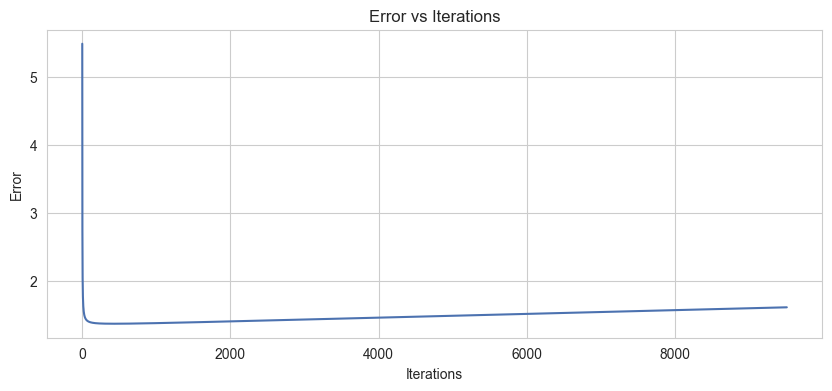

In [17]:
plot_errors(errors)

#### Plot Classifier

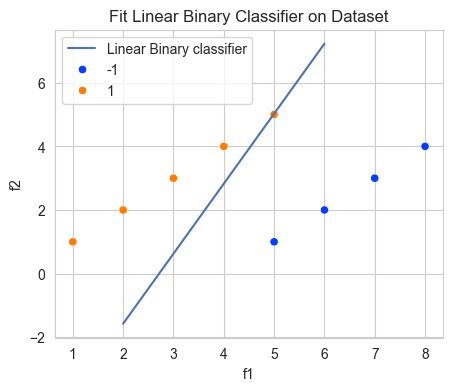

In [18]:
plt.figure(figsize=(5, 4))

# Plot Linear Binary classifier.
x = np.arange(2, 7)
w_1, w_2 = w[0][0], w[1][0]
y = (-w_1 / w_2) * x + (-w_0 / w_2)
plt.plot(x, y, label="Linear Binary classifier")

# Plot data-points.
sns.scatterplot(x=f1, y=f2, hue=cl, palette="bright")
plt.title("Fit Linear Binary Classifier on Dataset")
plt.xlabel("f1")
plt.ylabel("f2")

plt.show()

#### Observations

### 4.2 Example #2: Balanced Dataset

#### Test Dataset

In [19]:
f1 = [1, 2, 3, 4, 5, 6, 7, 8]  # Feature #1
f2 = [1, 2, 3, 4, 1, 2, 3, 4]  # Feature #2
cl = [1, 1, 1, 1, -1, -1, -1, -1]  # Class Label

d = 2  # Dimensions (Number of features)
n = len(cl)
X = np.column_stack((f1, f2))
Y = np.array(cl).reshape((n, 1))
data = np.concat((X, Y), axis=1)
rng.shuffle(data)

print("Dataset:")
display(data)
print("\nShape:", data.shape)

Dataset:


array([[ 3,  3,  1],
       [ 7,  3, -1],
       [ 1,  1,  1],
       [ 8,  4, -1],
       [ 2,  2,  1],
       [ 5,  1, -1],
       [ 6,  2, -1],
       [ 4,  4,  1]])


Shape: (8, 3)


#### Plot Dataset

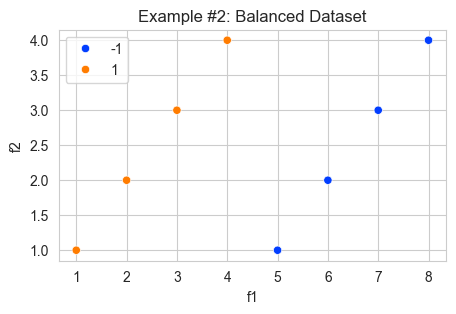

In [20]:
plt.figure(figsize=(5, 3))

sns.scatterplot(x=f1, y=f2, hue=cl, palette="bright")
plt.title("Example #2: Balanced Dataset")
plt.xlabel("f1")
plt.ylabel("f2")

plt.show()

#### Optimization

##### 1 Vanilla Gradient Descent

In [21]:
# # Hyper-parameters.
# eta = 0.003  # Learning Rate.
# lamda = 0.75  # Large value of lambda is recommended for small dataset.
# bias = 0.1

# w, w_0, errors = gradient_descent(X, Y, lr=eta, regularizer=lamda, bias=bias)

##### 2 Stochastic Gradient Descent

In [22]:
# # Hyper-parameters.
# eta = 0.5  # Learning Rate.
# lamda = 10  # Large value of lambda is recommended for small dataset.
# bias = 0

# w, w_0, errors = gradient_descent(X, Y, lr=eta, regularizer=lamda, batch_size=1)

##### 3 Mini-Batch Gradient Descent

In [23]:
# Hyper-parameters.
eta = 0.003  # Learning Rate.
lamda = 0.001  # Large value of lambda is recommended for small dataset.

w, w_0, errors = gradient_descent(X, Y, lr=eta, regularizer=lamda, batch_size=3)

It took 10000 epochs to find optimum weights.


C:\Users\dheem\AppData\Local\Temp\ipykernel_1700\2888503215.py:43: UserWarning: Max iteration reached. Try increasing learning rate.
  warnings.warn("Max iteration reached. Try increasing learning rate.")


#### Weights

In [24]:
print("First and last error:")
errors[0].round(6).item(), errors[-1].round(6).item()

First and last error:


(1.978179, 1.978179)

In [25]:
print("Optimum weights:", w.round(6).tolist())
print("Bias:", w_0)

Optimum weights: [[-215.066044], [-32.031786]]
Bias: [-10.]


https://www.desmos.com/calculator/jzq8echvg0

#### Plot Errors

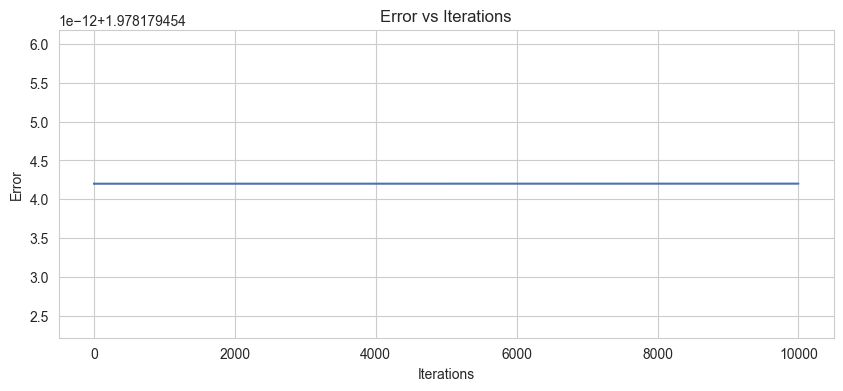

In [26]:
plot_errors(errors)

#### Plot Classifier

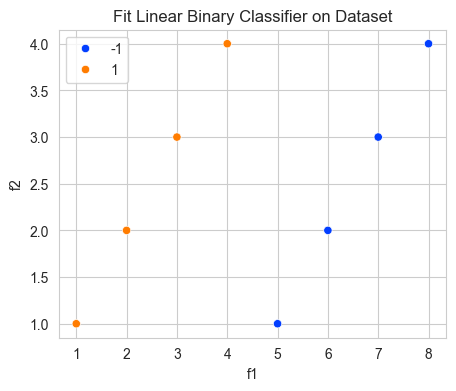

In [27]:
plt.figure(figsize=(5, 4))

# Plot Linear Binary classifier.
# x = np.arange(2, 7)
# w_1, w_2 = w[0][0], w[1][0]
# y = (-w_1 / w_2) * x + (-w_0 / w_2)
# plt.plot(x, y, label="Linear Binary classifier")

# Plot data-points.
sns.scatterplot(x=f1, y=f2, hue=cl, palette="bright")
plt.title("Fit Linear Binary Classifier on Dataset")
plt.xlabel("f1")
plt.ylabel("f2")

plt.show()

#### Observations

### 4.3 Example #3

#### Test Dataset

In [28]:
df = pd.read_csv("data/two_features_clf.csv")
display(df.sample(5, random_state=42))
df.shape

,f1,f2,cl
0,33.0,27.0,-1
17,50.3,89.5,1
15,73.0,114.8,1
1,13.0,6.5,-1
8,22.0,30.0,-1


(21, 3)

In [29]:
# Shuffle DataFrame before split.
df = df.sample(frac=1, ignore_index=True, random_state=42)

X = df[["f1", "f2"]].values
Y = df[["cl"]].values

X.shape, Y.shape

((21, 2), (21, 1))

#### Plot Dataset

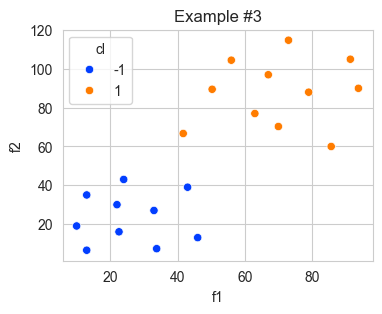

In [30]:
plt.figure(figsize=(4, 3))

sns.scatterplot(data=df, x="f1", y="f2", hue="cl", palette="bright")
plt.title("Example #3")
plt.xlabel("f1")
plt.ylabel("f2")

plt.show()

#### Optimization

##### 1 Vanilla Gradient Descent

In [31]:
# # Hyper-parameters.
# eta = 0.005  # Learning Rate.
# lamda = 0.01  # Large value of lambda is recommended for small dataset.
# bias = -0.1

# w, w_0, errors = gradient_descent(X, Y, lr=eta, regularizer=lamda, bias=bias)

##### 2 Stochastic Gradient Descent

In [32]:
# # Hyper-parameters.
# eta = 0.00001  # Learning Rate.
# lamda = 0.00001  # Large value of lambda is recommended for small dataset.
# bias = -100.5

# w, w_0, errors = gradient_descent(X, Y, lr=eta, regularizer=lamda, batch_size=1, bias=bias)

##### 3 Mini-Batch Gradient Descent

In [33]:
# Hyper-parameters.
eta = 0.01  # Learning Rate.
lamda = 15  # Large value of lambda is recommended for small dataset.

w, w_0, errors = gradient_descent(X, Y, lr=eta, regularizer=lamda, batch_size=4)

It took 9999 epochs to find optimum weights.


#### Weights

In [34]:
print("First and last error:")
errors[0].round(6).item(), errors[-1].round(6).item()

First and last error:


(40.247958, 37.281582)

In [35]:
print("Optimum weights:", w.round(6).tolist())
print("Bias:", w_0)

Optimum weights: [[0.236647], [0.766789]]
Bias: [-49.995]


https://www.desmos.com/calculator/pglvcmxyby

#### Plot Errors

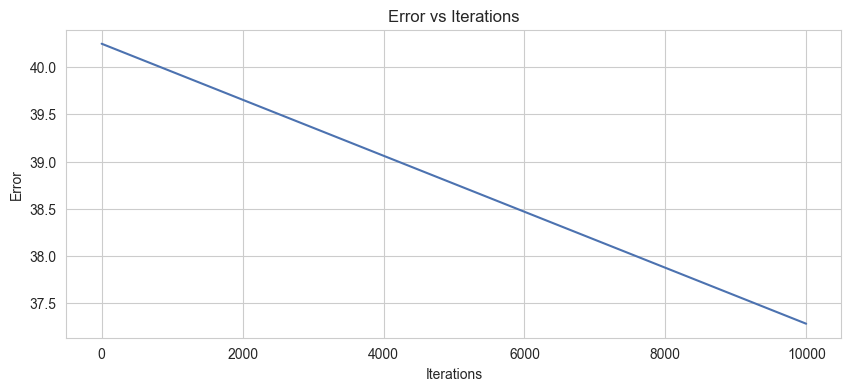

In [36]:
plot_errors(errors)

#### Plot Classifier

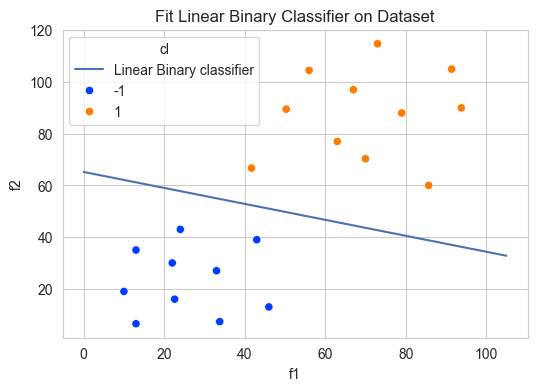

In [37]:
plt.figure(figsize=(6, 4))

# Plot Linear Binary classifier.
x = np.array([0, 105])
w_1, w_2 = w[0][0], w[1][0]
y = (-w_1 / w_2) * x + (-w_0 / w_2)
plt.plot(x, y, label="Linear Binary classifier")

# Plot data-points.
sns.scatterplot(data=df, x="f1", y="f2", hue="cl", palette="bright")
plt.title("Fit Linear Binary Classifier on Dataset")
plt.xlabel("f1")
plt.ylabel("f2")

plt.show()

#### Observations